In [33]:
from pathlib import Path

import numpy as np
import pandas as pd
import sklearn

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.decomposition import PCA

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel

from sklearn.metrics import r2_score,root_mean_squared_error, mean_squared_error, mean_absolute_error
from sklearn.model_selection import LeaveOneGroupOut

In [34]:
#File checker
DATA_DIR = Path("data")
data_files = sorted(
    p for p in DATA_DIR.iterdir()
    if p.suffix.lower() in {".csv"}#, ".parquet", ".pkl", ".pickle"}
)
df_raw = pd.read_csv(
    DATA_DIR / "perera_pfizer_raw_download.csv"
)
# df_raw = pd.read_csv(
#     PERERA_URL,
#     sep=";",
#     decimal=",",
#     encoding="utf-8-sig"
# )
print("Directory found:", DATA_DIR)
print("scikitlearn version:", sklearn.__version__)
print("Files found:")
for p in data_files:
    print(p.name)
    print(pd.read_csv(p, sep=",", decimal=",", encoding="utf-8-sig").shape)
    print(pd.read_csv(p, sep=",", decimal=",", encoding="utf-8-sig").head(1).columns.tolist())

Directory found: data
scikitlearn version: 1.9.0
Files found:
kraken_features_only.csv
(1223, 191)
['id', 'vmin_vmin_boltz', 'vmin_r_boltz', 'fmo_e_homo_boltz', 'fmo_e_lumo_boltz', 'fmo_mu_boltz', 'fmo_eta_boltz', 'fmo_omega_boltz', 'somo_ra_boltz', 'somo_rc_boltz', 'nbo_P_boltz', 'nbo_P_ra_boltz', 'spindens_P_ra_boltz', 'nbo_P_rc_boltz', 'spindens_P_rc_boltz', 'nmr_P_boltz', 'nmrtens_sxx_P_boltz', 'nmrtens_syy_P_boltz', 'nmrtens_szz_P_boltz', 'efg_amp_P_boltz', 'efgtens_xx_P_boltz', 'efgtens_yy_P_boltz', 'efgtens_zz_P_boltz', 'nuesp_P_boltz', 'E_solv_cds_boltz', 'nbo_lp_P_percent_s_boltz', 'nbo_lp_P_occ_boltz', 'nbo_lp_P_e_boltz', 'nbo_bd_e_max_boltz', 'nbo_bd_e_avg_boltz', 'nbo_bds_e_min_boltz', 'nbo_bds_e_avg_boltz', 'nbo_bd_occ_min_boltz', 'nbo_bd_occ_avg_boltz', 'nbo_bds_occ_max_boltz', 'nbo_bds_occ_avg_boltz', 'E_solv_total_boltz', 'E_solv_elstat_boltz', 'E_oxidation_boltz', 'E_reduction_boltz', 'fukui_p_boltz', 'fukui_m_boltz', 'vbur_vtot_boltz', 'vbur_ratio_vbur_vtot_boltz', 'P

In [70]:
#Load in data sets
df_interp= pd.read_csv(DATA_DIR /"perera_pfizer_group1_kraken_interpretable.csv")
df_full = pd.read_csv(DATA_DIR / "perera_pfizer_group1_kraken_full.csv")

#drop static  features
df_interp = df_interp.loc[:, df_interp.nunique(dropna=False) > 1].copy()
df_full = df_full.loc[:, df_full.nunique(dropna=False) > 1].copy()
 
#Target variable
TARGET = "Product_Yield_PCT_Area_UV"

#Non catalyst variables
non_catalyst = ["Reactant_2_Name", "Reactant_1_Name", "Solvent_1_Short_Hand", "ligand"]

#Drop additional yield feature
df_interp = df_interp.drop(columns=["Product_Yield_Mass_Ion_Count"])
df_full = df_full.drop(columns=["Product_Yield_Mass_Ion_Count"])

#Drop non needed reaction based features
df_interp = df_interp.drop(columns=["Reaction_No","Reactant_1_Short_Hand","Reagent_1_Short_Hand","Reagent_combo","reactant1_code","reactant2_code","substrate_pair","kraken_id"])
f_full = df_full.drop(columns=["Reaction_No","Reactant_1_Short_Hand","Reagent_1_Short_Hand","Reagent_combo","reactant1_code","reactant2_code","substrate_pair","kraken_id"])
#Drop catalyst features in interpretable set to only the 5 permitted
df_interp = df_interp.drop(columns=["vmin_vmin_boltz","fmo_e_homo_boltz","fmo_e_lumo_boltz","%vbur_max"])

In [58]:
for feature in df_interp.columns:
    print(f"{feature}: {df_interp[feature].nunique(dropna=False)} unique entries")

ligand: 8 unique entries
Reactant_1_Name: 4 unique entries
Reactant_2_Name: 3 unique entries
Solvent_1_Short_Hand: 4 unique entries
Product_Yield_PCT_Area_UV: 2510 unique entries
dipolemoment_boltz: 8 unique entries
%vbur_boltz: 8 unique entries
%vbur_min: 8 unique entries
%vbur_delta: 6 unique entries
delta_band_gap: 8 unique entries


In [37]:
cols_to_check = [
    "ligand",
    "kraken_id",
    "Catalyst_1_Short_Hand",
    "Solvent_1_Short_Hand",
    "Reagent_1_Short_Hand",
    "substrate_pair",
    "reaction_group",
    TARGET
]

for col in cols_to_check:
    print(f"\n{col}")
    print("unique:", df_interp[col].nunique(dropna=False))
    print("missing:", df_interp[col].isna().sum())


ligand
unique: 8
missing: 0

kraken_id
unique: 8
missing: 0

Catalyst_1_Short_Hand
unique: 1
missing: 0

Solvent_1_Short_Hand
unique: 4
missing: 0

Reagent_1_Short_Hand
unique: 8
missing: 384

substrate_pair
unique: 12
missing: 0

reaction_group
unique: 1
missing: 0

Product_Yield_PCT_Area_UV
unique: 2510
missing: 0


In [38]:
for col in [
    "ligand",
    "Catalyst_1_Short_Hand",
    "Solvent_1_Short_Hand",
    "Reagent_1_Short_Hand",
    "substrate_pair",
    "reaction_group"
]:
    print(f"\n--- {col} ---")
    print(df_interp[col].value_counts(dropna=False))


--- ligand ---
ligand
P(tBu)3        384
P(Ph)3         384
AmPhos         384
P(Cy)3         384
P(o-Tol)3      384
CataCXium A    384
SPhos          384
XPhos          384
Name: count, dtype: int64

--- Catalyst_1_Short_Hand ---
Catalyst_1_Short_Hand
Pd(OAc)2    3072
Name: count, dtype: int64

--- Solvent_1_Short_Hand ---
Solvent_1_Short_Hand
MeCN    768
THF     768
DMF     768
MeOH    768
Name: count, dtype: int64

--- Reagent_1_Short_Hand ---
Reagent_1_Short_Hand
NaOH      384
NaHCO3    384
CsF       384
K3PO4     384
KOH       384
LiOtBu    384
Et3N      384
NaN       384
Name: count, dtype: int64

--- substrate_pair ---
substrate_pair
1a_2a    256
1b_2a    256
1c_2a    256
1d_2a    256
1c_2b    256
1d_2b    256
1b_2b    256
1a_2b    256
1c_2c    256
1d_2c    256
1b_2c    256
1a_2c    256
Name: count, dtype: int64

--- reaction_group ---
reaction_group
Group1    3072
Name: count, dtype: int64


In [39]:
df_interp[TARGET].describe()

count    3072.000000
mean       47.643415
std        30.100110
min         0.000000
25%        17.285000
50%        46.815000
75%        75.422500
max       100.000000
Name: Product_Yield_PCT_Area_UV, dtype: float64

In [41]:
ligand_mapping = (
    df_interp[["ligand", "kraken_id"]]
    .drop_duplicates()
    .sort_values("ligand")
)

display(ligand_mapping)

,ligand,kraken_id
2,AmPhos,216
5,CataCXium A,10
3,P(Cy)3,11
1,P(Ph)3,17
4,P(o-Tol)3,9
0,P(tBu)3,8
6,SPhos,3
7,XPhos,1


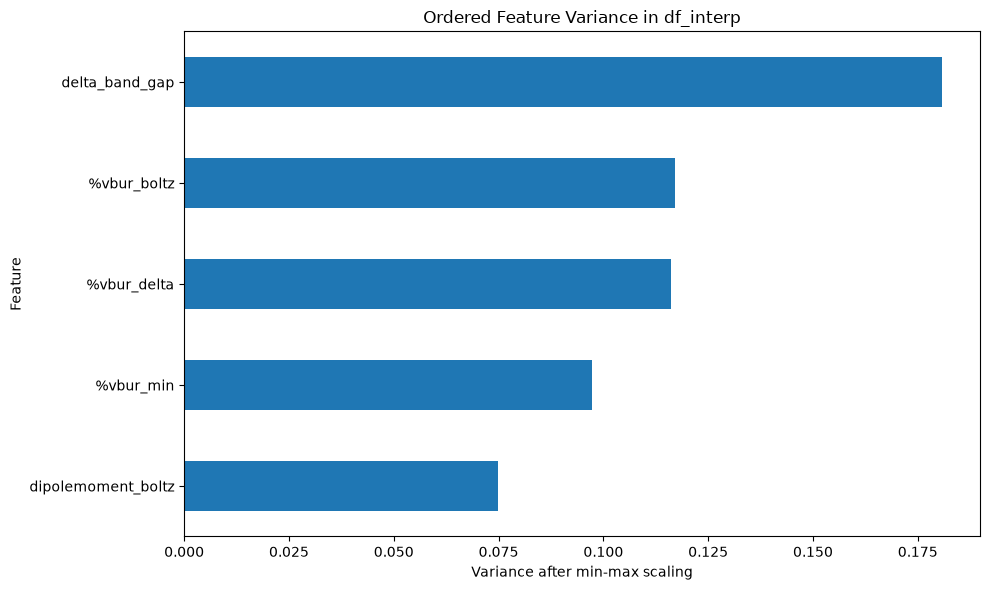

In [59]:
import matplotlib.pyplot as plt

numeric_features = df_interp.drop(columns=TARGET).select_dtypes(include=np.number)

scaled_features = (numeric_features - numeric_features.min()) / (
    numeric_features.max() - numeric_features.min()
)
scaled_variance = scaled_features.var().fillna(0).sort_values()

plt.figure(figsize=(10, 6))
scaled_variance.plot(kind="barh")
plt.xlabel("Variance after min-max scaling")
plt.ylabel("Feature")
plt.title("Ordered Feature Variance in df_interp")
plt.tight_layout()
plt.show()

In [ ]:
for feature in df_interp.columns:
    print(f"{feature}: {df_interp[feature].nunique(dropna=False)} unique entries")

ligand: 8 unique entries
Reactant_1_Name: 4 unique entries
Reactant_2_Name: 3 unique entries
Solvent_1_Short_Hand: 4 unique entries
Product_Yield_PCT_Area_UV: 2510 unique entries
dipolemoment_boltz: 8 unique entries
%vbur_boltz: 8 unique entries
%vbur_min: 8 unique entries
%vbur_delta: 6 unique entries
delta_band_gap: 8 unique entries


In [62]:
for feature in df_full.columns:
    print(f"{feature}: {df_full[feature].nunique(dropna=False)} unique entries")

Reaction_No: 3072 unique entries
Reactant_1_Name: 4 unique entries
Reactant_1_Short_Hand: 4 unique entries
Reactant_2_Name: 3 unique entries
Ligand_Short_Hand: 8 unique entries
Reagent_1_Short_Hand: 8 unique entries
Solvent_1_Short_Hand: 4 unique entries
Product_Yield_PCT_Area_UV: 2510 unique entries
Reagent_combo: 96 unique entries
reactant1_code: 4 unique entries
reactant2_code: 3 unique entries
substrate_pair: 12 unique entries
kraken_id: 8 unique entries
vmin_vmin_boltz: 8 unique entries
vmin_r_boltz: 8 unique entries
fmo_e_homo_boltz: 8 unique entries
fmo_e_lumo_boltz: 8 unique entries
fmo_mu_boltz: 8 unique entries
fmo_eta_boltz: 8 unique entries
fmo_omega_boltz: 8 unique entries
somo_ra_boltz: 8 unique entries
somo_rc_boltz: 8 unique entries
nbo_P_boltz: 8 unique entries
nbo_P_ra_boltz: 8 unique entries
spindens_P_ra_boltz: 8 unique entries
nbo_P_rc_boltz: 8 unique entries
spindens_P_rc_boltz: 8 unique entries
nmr_P_boltz: 8 unique entries
nmrtens_sxx_P_boltz: 8 unique entries
n

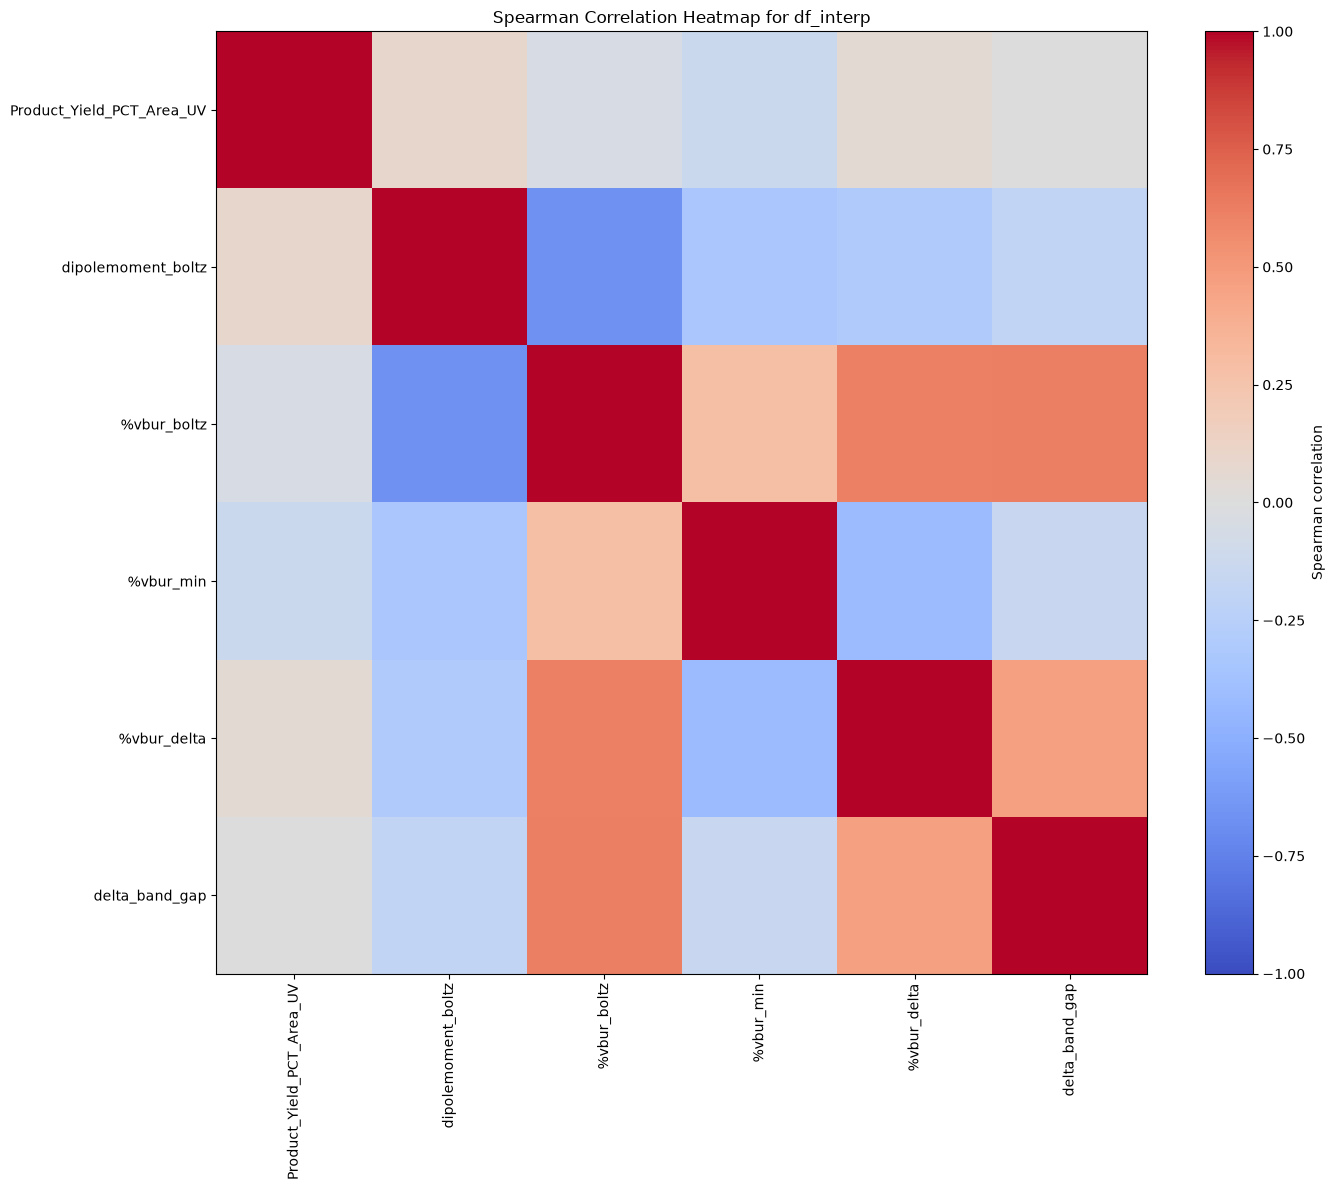

In [66]:
spearman_corr = df_interp.select_dtypes(include=np.number).corr(method="spearman")

plt.figure(figsize=(14, 12))
plt.imshow(spearman_corr, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")
plt.colorbar(label="Spearman correlation")
plt.xticks(range(len(spearman_corr.columns)), spearman_corr.columns, rotation=90)
plt.yticks(range(len(spearman_corr.index)), spearman_corr.index)
plt.title("Spearman Correlation Heatmap for df_interp")
plt.tight_layout()
plt.show()

In [64]:
from scipy.stats import chi2_contingency

# Test associations between categorical features and binned product yield
yield_bins = pd.qcut(df_interp[TARGET], q=4, duplicates="drop")

categorical_features = df_interp.drop(columns=TARGET).select_dtypes(
    include=["object", "category"]
).columns

chi_square_results = []

for feature in categorical_features:
    contingency_table = pd.crosstab(df_interp[feature], yield_bins)
    
    if contingency_table.shape[0] > 1 and contingency_table.shape[1] > 1:
        chi2, p_value, dof, expected = chi2_contingency(contingency_table)
        n = contingency_table.to_numpy().sum()
        cramers_v = np.sqrt(chi2 / (n * min(contingency_table.shape[0] - 1,
                                             contingency_table.shape[1] - 1)))
        
        chi_square_results.append({
            "feature": feature,
            "chi2": chi2,
            "p_value": p_value,
            "dof": dof,
            "cramers_v": cramers_v,
        })

chi_square_results = pd.DataFrame(chi_square_results).sort_values("p_value")
display(chi_square_results)

C:\Users\kagoble\AppData\Local\Temp\ipykernel_52008\2509159096.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df_interp.drop(columns=TARGET).select_dtypes(


,feature,chi2,p_value,dof,cramers_v
2,Reactant_2_Name,831.937500,1.933066e-176,6,0.367976
1,Reactant_1_Name,708.135417,1.232560e-146,9,0.277196
3,Solvent_1_Short_Hand,428.312500,1.236398e-86,9,0.215580
0,ligand,157.270833,7.214245e-23,21,0.130633


,feature,relevance,redundancy,mrmr_score
0,delta_band_gap,0.019841,0.000000,0.019841
1,%vbur_delta,0.011528,0.736842,-0.725314
2,%vbur_boltz,0.019260,0.822967,-0.803706
3,dipolemoment_boltz,0.017431,0.851675,-0.834244
4,%vbur_min,0.019260,0.888756,-0.869496


In [ ]:
OneHotEncoder(handle_unknown="ignore",sparse_output=False)

In [ ]:
from feature_engine.selection import MRMR
from sklearn.impute import SimpleImputer

X_interp = df_interp.drop(columns=[TARGET]).copy()
y_interp = df_interp[TARGET].copy()

categorical_cols = X_interp.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X_interp.select_dtypes(include=np.number).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            SimpleImputer(strategy="median"),
            numeric_cols,
        ),
        (
            "categorical",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
                ]
            ),
            categorical_cols,
        ),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

X_interp_encoded = pd.DataFrame(
    preprocessor.fit_transform(X_interp),
    columns=preprocessor.get_feature_names_out(),
    index=X_interp.index,
)

mrmr = MRMR(
    max_features=min(20, X_interp_encoded.shape[1]),
    scoring="f_test",
    regression=True,
    random_state=42,
)
mrmr.fit(X_interp_encoded, y_interp)

selected_features = list(mrmr.get_feature_names_out())
X_interp_mrmr = mrmr.transform(X_interp_encoded)

mrmr_results = pd.DataFrame(
    {
        "rank": range(1, len(selected_features) + 1),
        "feature": selected_features,
    }
)

mrmr_values = X_interp_encoded.loc[:, selected_features].copy()
mrmr_values.insert(0, TARGET, y_interp)

display(mrmr_results)
display(mrmr_values)
print("Encoded feature matrix:", X_interp_encoded.shape)
print("MRMR feature matrix:", X_interp_mrmr.shape)


C:\Users\kagoble\AppData\Local\Temp\ipykernel_52008\1452451199.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_interp.select_dtypes(include=["object", "category"]).columns.tolist()
C:\Users\kagoble\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\feature_engine\selection\mrmr.py:465: RuntimeWarning: divide by zero encountered in divide
  mrmr = relevance / redundance
C:\Users\kagoble\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-p

,rank,feature
0,1,dipolemoment_boltz
1,2,%vbur_min
2,3,delta_band_gap
3,4,ligand_AmPhos
4,5,ligand_CataCXium A
5,6,ligand_P(Ph)3
6,7,ligand_P(o-Tol)3
7,8,ligand_P(tBu)3
8,9,ligand_SPhos
9,10,Reactant_1_Name_6-Bromoquinoline


Encoded feature matrix: (3072, 24)
MRMR feature matrix: (3072, 20)
